In [2]:
## If there are issues with the imports, uncomment the lines in this box##

#!pip uninstall -y art adversarial_robustness_toolbox keras tensorflow
#!pip cache purge
#!pip install art
#!pip install tensorflow
#!pip install adversarial-robustness-toolbox
#!pip install keras

Found existing installation: keras 3.4.1
Uninstalling keras-3.4.1:
  Successfully uninstalled keras-3.4.1
Found existing installation: tensorflow 2.17.0
Uninstalling tensorflow-2.17.0:
  Successfully uninstalled tensorflow-2.17.0
Files removed: 0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 606.3/606.3 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.3/601.3 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 22.9 MB/s eta 0:00:00


In [3]:
import warnings
import os
import art
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from keras.losses import CategoricalCrossentropy
from keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from art.utils import check_and_transform_label_format
from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.evasion import ProjectedGradientDescent, FastGradientMethod
from PIL import Image
from art import config
warnings.filterwarnings('ignore')

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
data = np.load('/content/drive/MyDrive/CSCI4880 Group Project/Group Project/processed_dataset.npz')
image_data = data['image_data']
image_labels = data['image_labels']
model = load_model('/content/drive/MyDrive/CSCI4880 Group Project/Group Project/Garfunkle_Model.h5')
model.load_weights('/content/drive/MyDrive/CSCI4880 Group Project/Group Project/Garfunkle.weights.h5')
X_train, X_test, y_train, y_test = train_test_split(image_data, image_labels, test_size=0.2, random_state=309)

In [6]:
y_pred=model.predict(X_test)
original_accuracy = accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1))
print(f'Original Accuracy: {original_accuracy * 100:.2f}%')

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Original Accuracy: 95.82%


In [7]:
classifier = TensorFlowV2Classifier(model=model, nb_classes=22, input_shape=(75,60), loss_object=tf.keras.losses.CategoricalCrossentropy(), clip_values=(0, 1))
pgd_attack = ProjectedGradientDescent(estimator=classifier, eps=0.3, eps_step=0.1, max_iter=100)
X_test_adv_pgd = pgd_attack.generate(X_test)

PGD - Batches: 0it [00:00, ?it/s]

In [8]:
pgd_y_pred = model.predict(X_test_adv_pgd)
pgd_accuracy = accuracy_score(np.argmax(y_test, axis=1), np.argmax(pgd_y_pred, axis=1))
print(f'Accuracy on adversarial examples: {pgd_accuracy * 100:.2f}%')
print(f'Original Accuracy: {original_accuracy * 100:.2f}%')
print(f'Difference: {abs(original_accuracy - pgd_accuracy) * 100:.2f}%')

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy on adversarial examples: 27.45%
Original Accuracy: 95.82%
Difference: 68.38%


In [9]:
fgsm_attack = FastGradientMethod(estimator=classifier, eps=0.3, eps_step=0.1)
X_test_adv_fgsm = fgsm_attack.generate(X_test)

In [10]:
fgsm_y_pred = model.predict(X_test_adv_fgsm)
fgsm_accuracy = accuracy_score(np.argmax(y_test, axis=1), np.argmax(fgsm_y_pred, axis=1))
print(f'Accuracy on FGSM adversarial examples: {fgsm_accuracy * 100:.2f}%')
print(f'Original Accuracy: {original_accuracy * 100:.2f}%')
print(f'Difference: {abs(original_accuracy - fgsm_accuracy) * 100:.2f}%')

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy on FGSM adversarial examples: 33.88%
Original Accuracy: 95.82%
Difference: 61.94%


In [35]:
class_map = {
    0: "Man and his Occupations",
    1: "Parts of the Human Body",
    2: "Mammals",
    3: "Parts of Mammals",
    4: "Birds",
    5: "Parts of Birds",
    6: "Amphibious Animals, Reptiles, etc.",
    7: "Invertebrates and Lesser Animals",
    8: "Trees and Plants",
    9: "Sky, Earth, and Water",
    10: "Buildings, Parts of Buildings, etc.",
    11: "Ships and Parts of Ships",
    12: "Domestic and Funerary Furniture",
    13: "Temple Furniture and Sacred Emblems",
    14: "Crown, Dress, and Staves",
    15: "Warfare, Hunting, Butchery",
    16: "Agriculture, Crafts, and Professions",
    17: "Rope, Fiber, Baskets, Bags, etc.",
    18: "Vessels of Stone and Earthenware",
    19: "Loaves and Cakes",
    20: "Writings, Games, Music",
    21: "Strokes, Signs Derived from Hieratic"
}

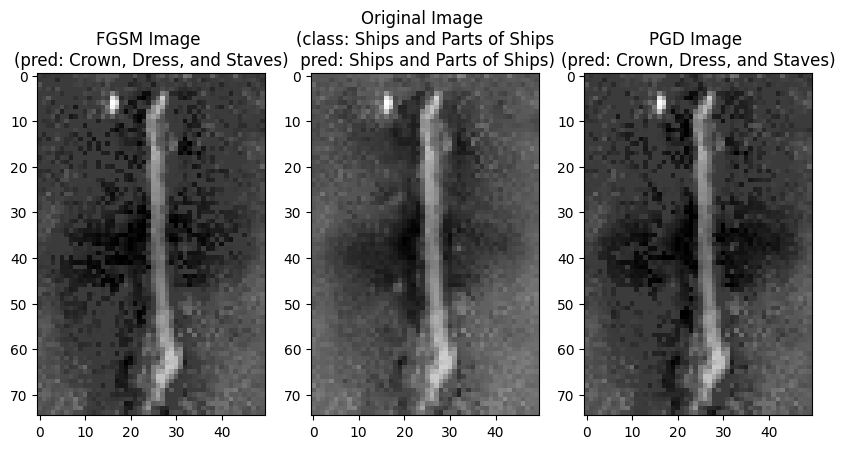

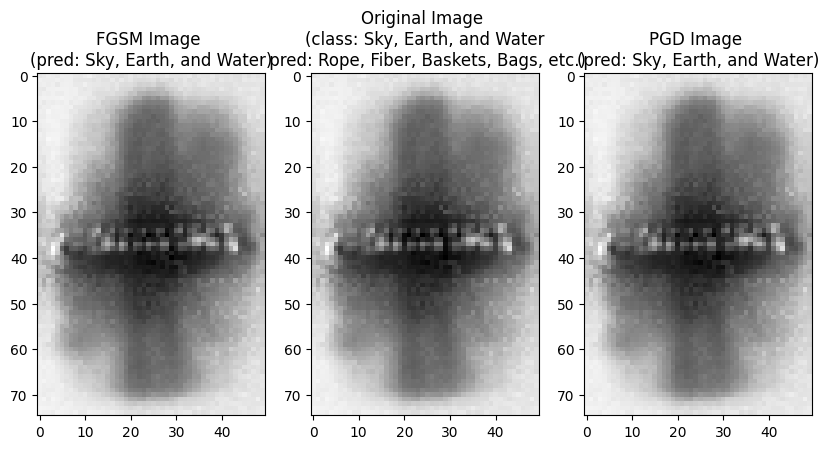

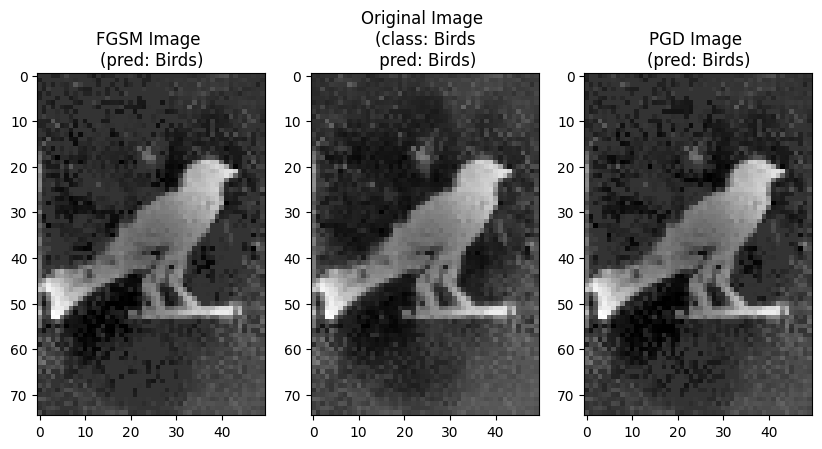

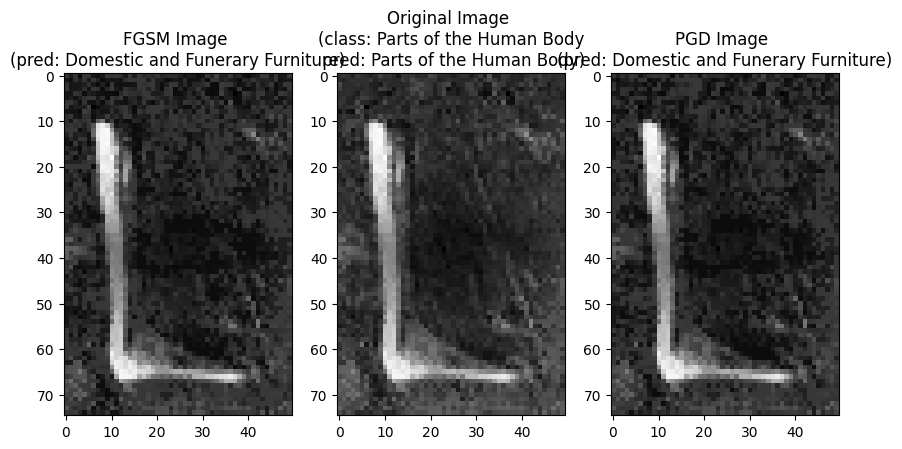

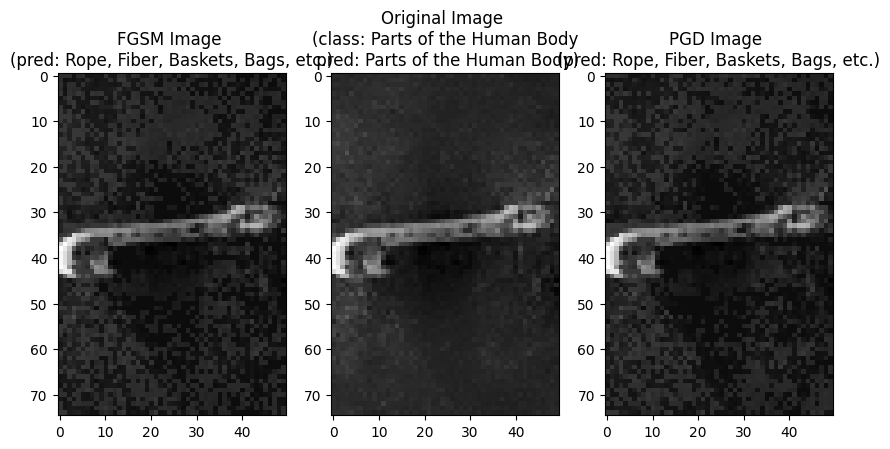

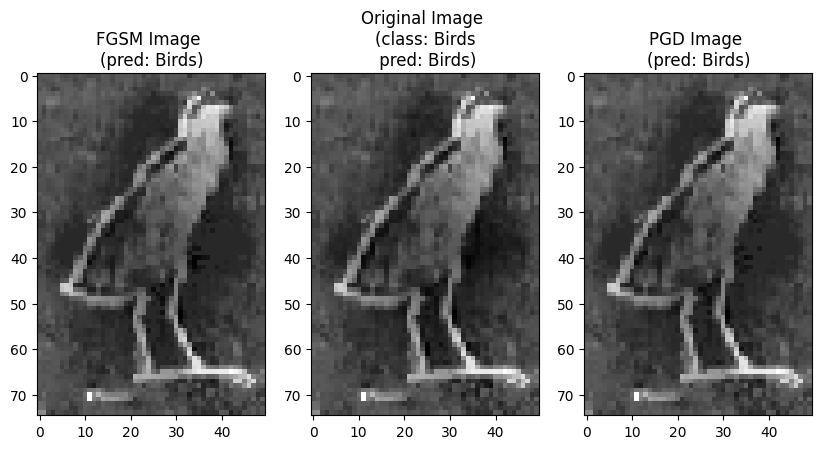

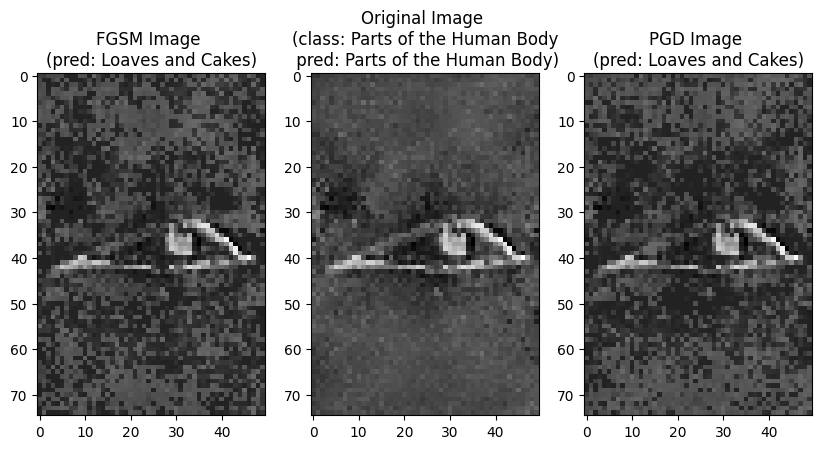

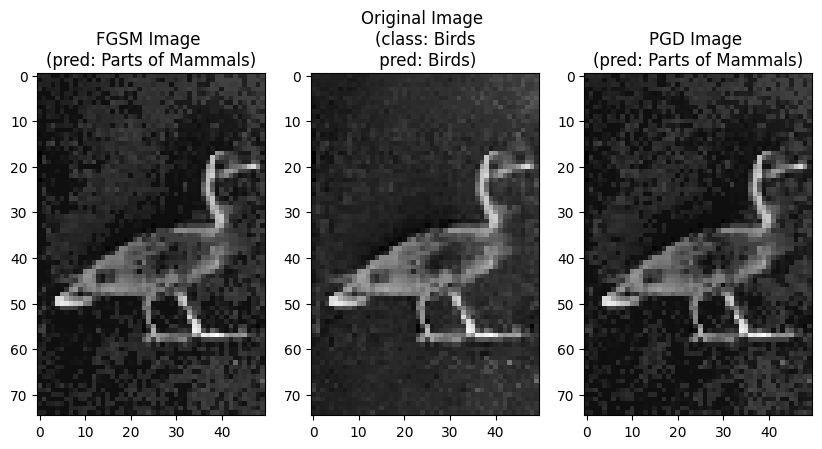

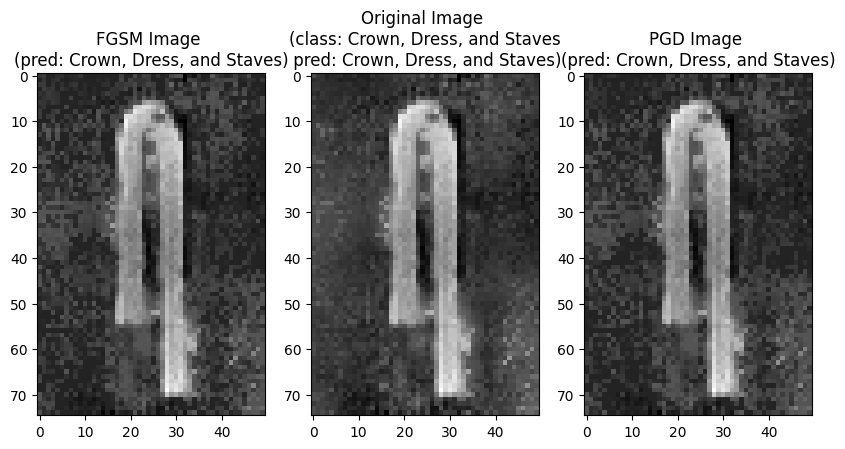

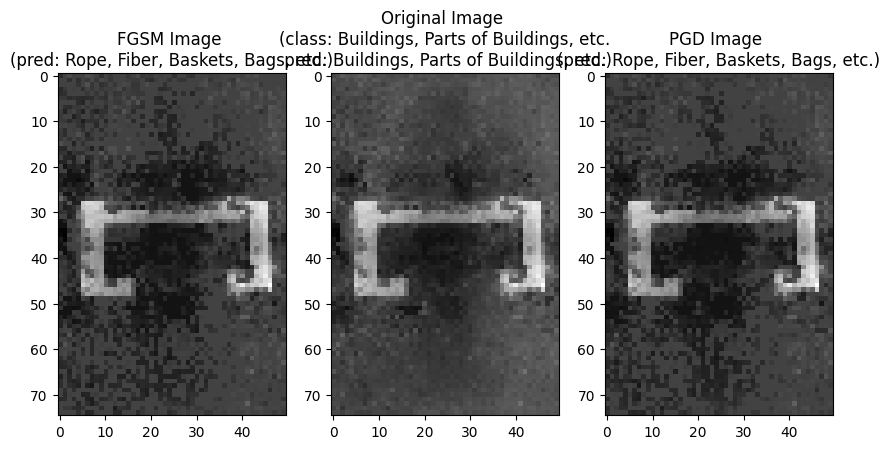

In [37]:
for i in np.random.choice(len(X_test), size=10, replace=False):
    fig, ax = plt.subplots(1, 3, figsize=(10, 5))
    ax[0].imshow(X_test_adv_fgsm[i].reshape(75, 50), cmap='Greys')
    ax[0].set_title(f'FGSM Image \n(pred: {class_map[np.argmax(fgsm_y_pred[i])]})')
    ax[1].imshow(X_test[i].reshape(75, 50), cmap='Greys')
    ax[1].set_title(f'Original Image \n(class: {class_map[np.argmax(y_test[i])]}\n pred: {class_map[np.argmax(y_pred[i])]})')
    ax[2].imshow(X_test_adv_pgd[i].reshape(75, 50), cmap='Greys')
    ax[2].set_title(f'PGD Image \n(pred: {class_map[np.argmax(pgd_y_pred[i])]})')

In [12]:
X_train_adv_pgd = pgd_attack.generate(X_train)
X_train_adv_fgsm = fgsm_attack.generate(X_train)

PGD - Batches: 0it [00:00, ?it/s]

In [13]:
X_train_combined_pgd = np.concatenate((X_train, X_train_adv_pgd))
y_train_combined_pgd = np.concatenate((y_train, y_train))
X_test_combined_pgd = np.concatenate((X_test, X_test_adv_pgd))
y_test_combined_pgd = np.concatenate((y_test, y_test))

In [14]:
X_train_combined_fgsm = np.concatenate((X_train, X_train_adv_fgsm))
y_train_combined_fgsm = np.concatenate((y_train, y_train))
X_test_combined_fgsm = np.concatenate((X_test, X_test_adv_fgsm))
y_test_combined_fgsm = np.concatenate((y_test, y_test))

In [15]:
X_train_combined_both = np.concatenate((X_train, X_train_adv_pgd, X_train_adv_fgsm))
y_train_combined_both = np.concatenate((y_train, y_train, y_train))
X_test_combined_both = np.concatenate((X_test, X_test_adv_pgd, X_test_adv_fgsm))
y_test_combined_both = np.concatenate((y_test, y_test, y_test))

In [16]:
def reset_weights(model):
    for layer in model.layers:
        if hasattr(layer, 'kernel_initializer') and hasattr(layer, 'bias_initializer'):
            layer.kernel.assign(layer.kernel_initializer(tf.shape(layer.kernel)))
            layer.bias.assign(layer.bias_initializer(tf.shape(layer.bias)))

In [17]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [18]:
reset_weights(model)

In [19]:
model.fit(X_train_combined_pgd, y_train_combined_pgd, epochs=20, batch_size=64)
y_pred_def_pgd = model.predict(X_test_combined_pgd)
def_pgd_accuracy = accuracy_score(np.argmax(y_test_combined_pgd, axis=1), np.argmax(y_pred_def_pgd, axis=1))
print(f'Accuracy on PGD defended examples: {def_pgd_accuracy * 100:.2f}%')
print(f'Original adversarial accuracy: {pgd_accuracy * 100:.2f}%')
print(f'Difference: {abs(pgd_accuracy - def_pgd_accuracy) * 100:.2f}%')
print(f'Original accuracy: {original_accuracy * 100:2f}%')
print(f'Defended Difference: {abs(original_accuracy - def_pgd_accuracy) * 100:2f}%')

Epoch 1/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.5805 - loss: 6.1209
Epoch 2/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8186 - loss: 2.4564
Epoch 3/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8370 - loss: 1.6937
Epoch 4/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8424 - loss: 1.4503
Epoch 5/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8565 - loss: 1.2769
Epoch 6/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8452 - loss: 1.2304
Epoch 7/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8776 - loss: 1.0581
Epoch 8/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8882 - loss: 0.9601
Epoch 9/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8740 - loss: 1.0100
Epoch 10/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9038 - loss: 0.8422
Epoch 11/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9070 - loss: 0.8023
Epoch 12/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

In [20]:
reset_weights(model)

In [21]:
model.fit(X_train_combined_fgsm, y_train_combined_fgsm, epochs=20, batch_size=64)
y_pred_def_fgsm = model.predict(X_test_combined_fgsm)
def_fgsm_accuracy = accuracy_score(np.argmax(y_test_combined_fgsm, axis=1), np.argmax(y_pred_def_fgsm, axis=1))
print(f'Accuracy on FGSM defended examples: {def_fgsm_accuracy * 100:.2f}%')
print(f'Original adversarial accuracy: {fgsm_accuracy * 100:.2f}%')
print(f'Difference: {abs(fgsm_accuracy - def_fgsm_accuracy) * 100:.2f}%')
print(f'Original accuracy: {original_accuracy * 100:2f}%')
print(f'Defended Difference: {abs(original_accuracy - def_fgsm_accuracy) * 100:2f}%')

Epoch 1/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4374 - loss: 8.2154
Epoch 2/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7413 - loss: 2.5195
Epoch 3/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7824 - loss: 1.9220
Epoch 4/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7879 - loss: 1.6392
Epoch 5/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8158 - loss: 1.3987
Epoch 6/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8325 - loss: 1.2602
Epoch 7/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8503 - loss: 1.1208
Epoch 8/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8607 - loss: 1.0568
Epoch 9/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8627 - loss: 0.9760
Epoch 10/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8837 - loss: 0.8798
Epoch 11/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8799 - loss: 0.8677
Epoch 12/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

In [22]:
reset_weights(model)

In [23]:
model.fit(X_train_combined_both, y_train_combined_both, epochs=20, batch_size=64)
y_pred_def_both = model.predict(X_test_combined_both)
def_both_accuracy = accuracy_score(np.argmax(y_test_combined_both, axis=1), np.argmax(y_pred_def_both, axis=1))
print(f'Accuracy on dual defended examples: {def_both_accuracy * 100:.2f}%')
print(f'Original accuracy: {original_accuracy * 100:2f}%')
print(f'Defended Difference: {abs(original_accuracy - def_both_accuracy) * 100:2f}%')

Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4937 - loss: 7.4942
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7784 - loss: 2.0038
Epoch 3/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8076 - loss: 1.5479
Epoch 4/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8395 - loss: 1.2429
Epoch 5/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8512 - loss: 1.1073
Epoch 6/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8711 - loss: 0.9648
Epoch 7/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8810 - loss: 0.8869
Epoch 8/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8980 - loss: 0.7908
Epoch 9/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9059 - loss: 0.7639
Epoch 10/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9221 - loss: 0.6762
Epoch 11/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9194 - loss: 0.6924
Epoch 12/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

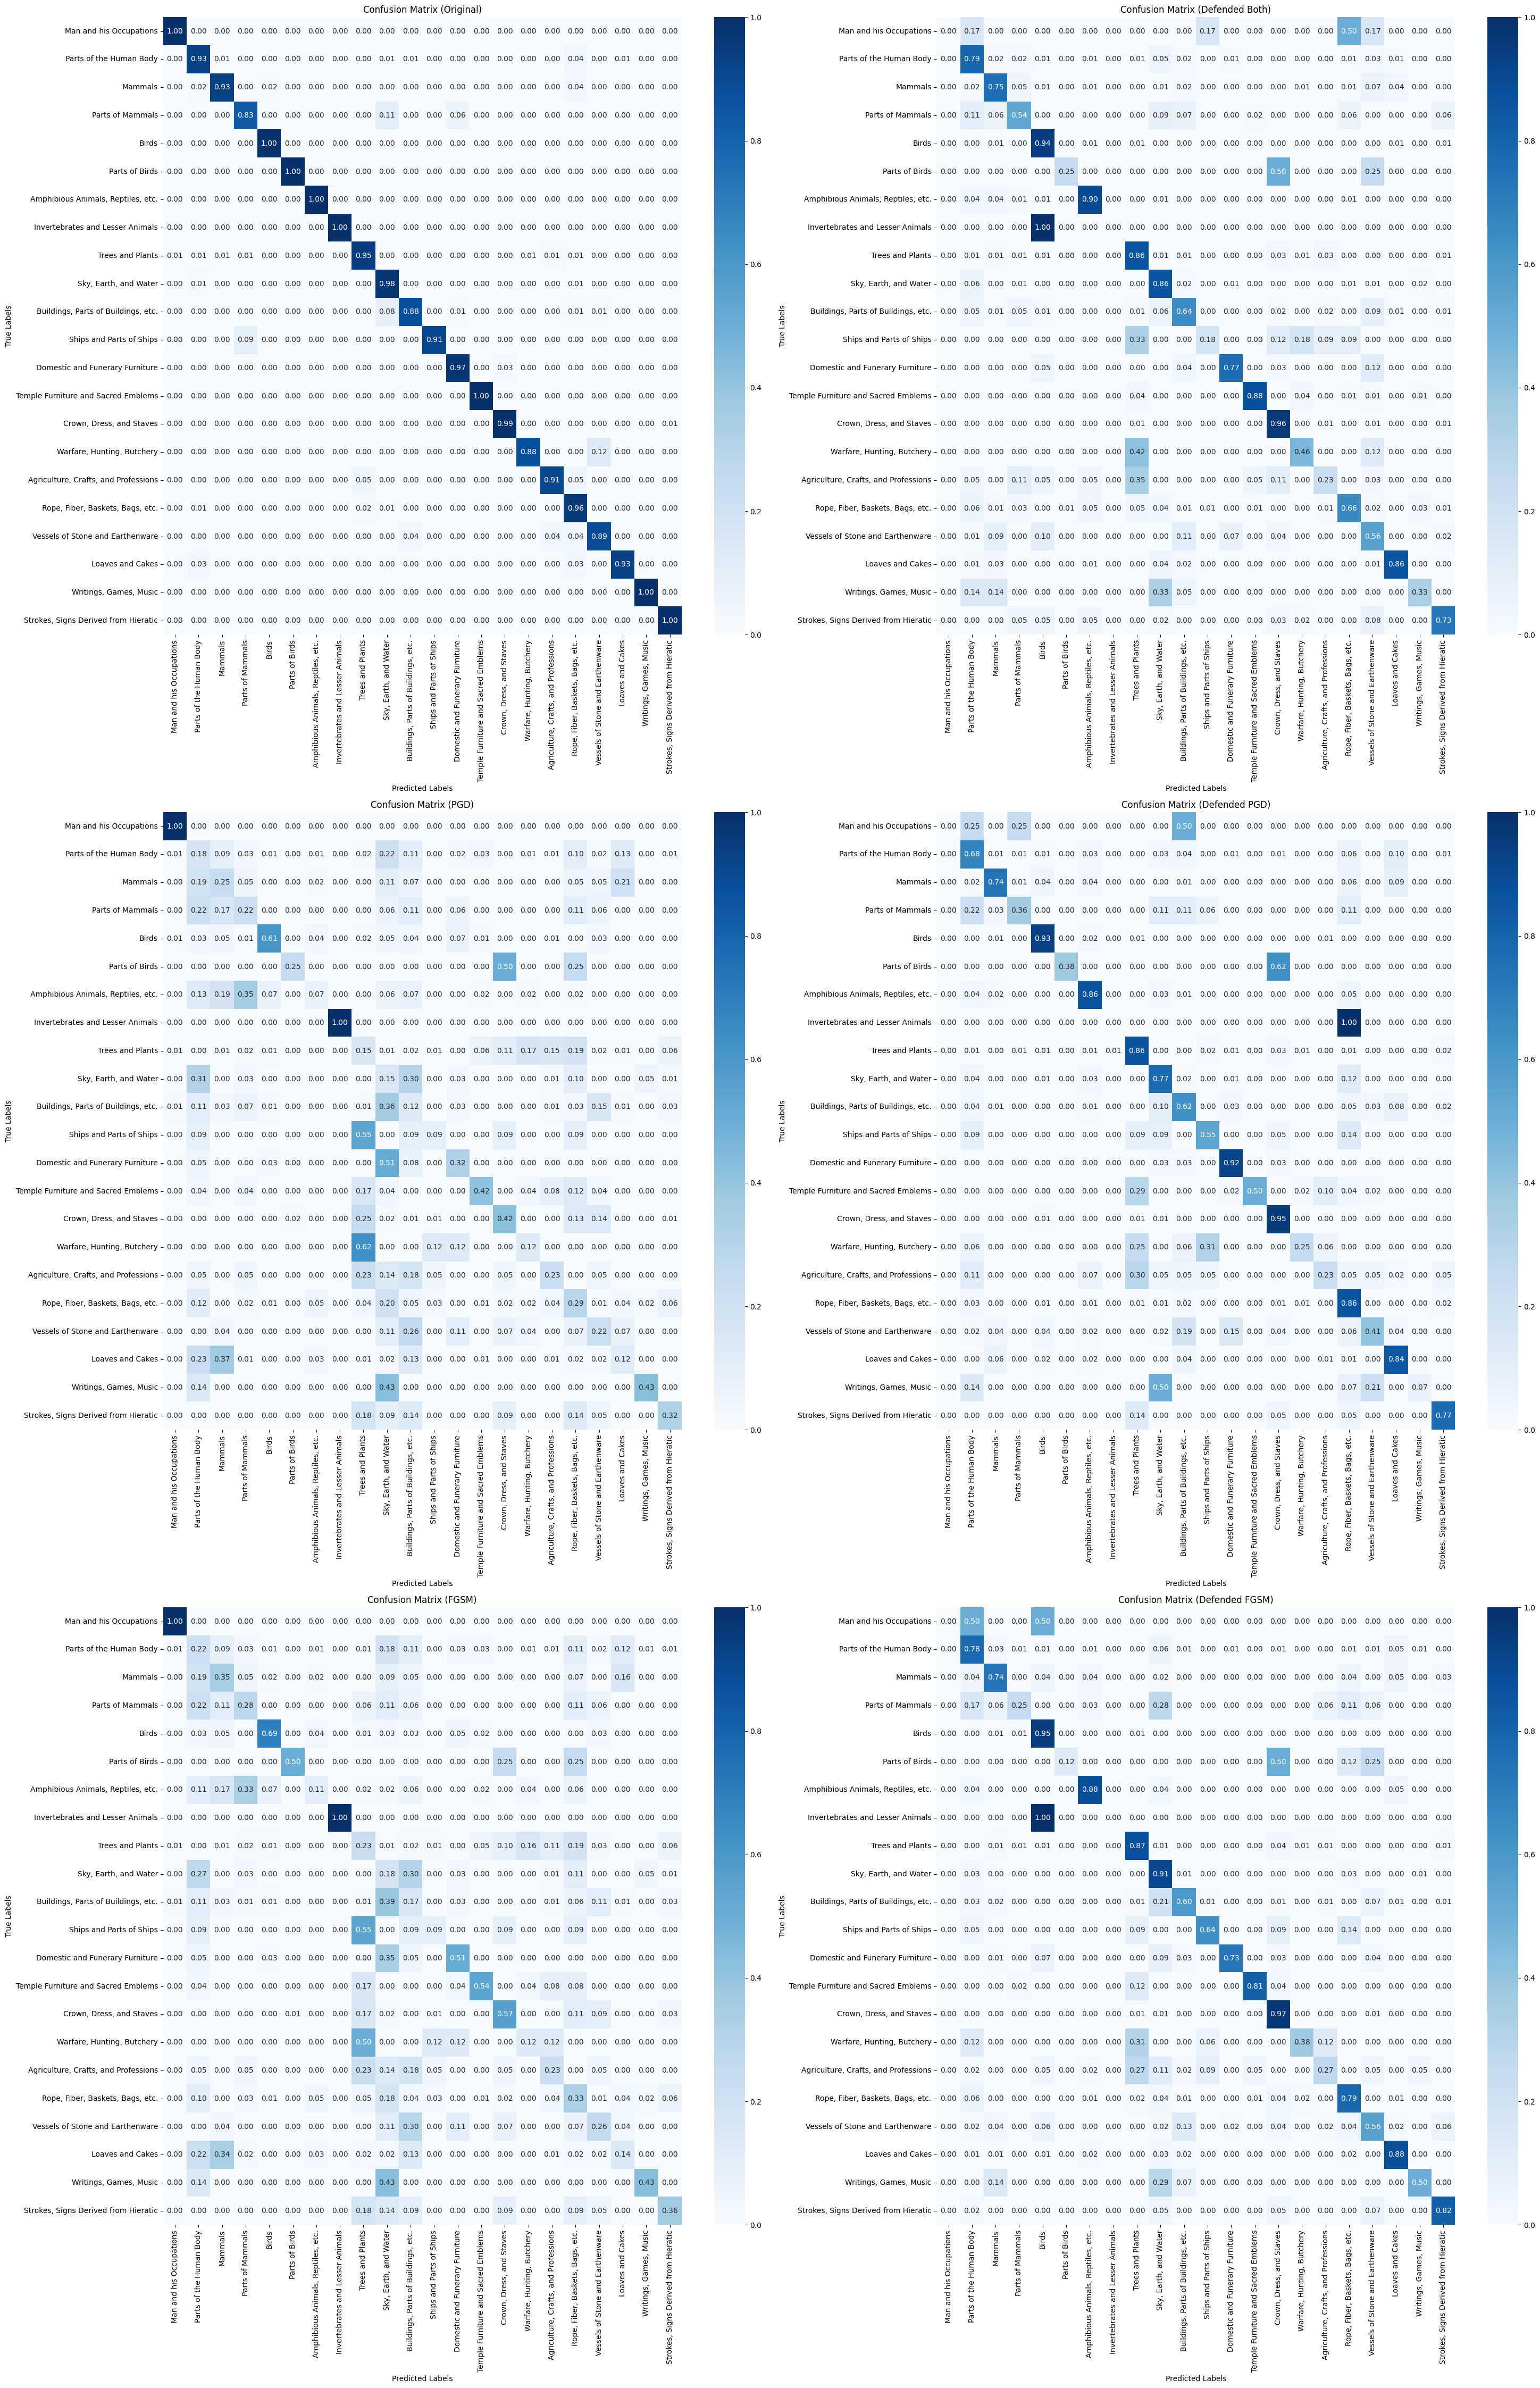

In [39]:
category_names = [class_map[i] for i in range(len(class_map))]
conf_matrix_orig = confusion_matrix(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1))
row_sums = conf_matrix_orig.sum(axis=1)[:, np.newaxis]
conf_matrix_orig_n = conf_matrix_orig / row_sums
conf_matrix_pdg = confusion_matrix(np.argmax(y_test, axis=1), np.argmax(pgd_y_pred, axis=1))
row_sums = conf_matrix_pdg.sum(axis=1)[:, np.newaxis]
conf_matrix_pgd_n = conf_matrix_pdg / row_sums
conf_matrix_fgsm = confusion_matrix(np.argmax(y_test, axis=1), np.argmax(fgsm_y_pred, axis=1))
row_sums = conf_matrix_fgsm.sum(axis=1)[:, np.newaxis]
conf_matrix_fgsm_n = conf_matrix_fgsm / row_sums
conf_matrix_def_pgd = confusion_matrix(np.argmax(y_test_combined_pgd, axis=1), np.argmax(y_pred_def_pgd, axis=1))
row_sums = conf_matrix_def_pgd.sum(axis=1)[:, np.newaxis]
conf_matrix_def_pgd_n = conf_matrix_def_pgd / row_sums
conf_matrix_def_fgsm = confusion_matrix(np.argmax(y_test_combined_fgsm, axis=1), np.argmax(y_pred_def_fgsm, axis=1))
row_sums = conf_matrix_def_fgsm.sum(axis=1)[:, np.newaxis]
conf_matrix_def_fgsm_n = conf_matrix_def_fgsm / row_sums
conf_matrix_def_both = confusion_matrix(np.argmax(y_test_combined_both, axis=1), np.argmax(y_pred_def_both, axis=1))
row_sums = conf_matrix_def_both.sum(axis=1)[:, np.newaxis]
conf_matrix_def_both_n = conf_matrix_def_both / row_sums
fig, ax = plt.subplots(3, 2, figsize=(30, 45))

sns.heatmap(conf_matrix_orig_n, annot=True, cmap='Blues', ax=ax[0, 0], fmt='.2f',xticklabels=category_names, yticklabels=category_names)
ax[0, 0].set_xlabel('Predicted Labels')
ax[0, 0].set_ylabel('True Labels')
ax[0, 0].set_title('Confusion Matrix (Original)')

sns.heatmap(conf_matrix_pgd_n, annot=True, cmap='Blues', ax=ax[1, 0], fmt='.2f',xticklabels=category_names, yticklabels=category_names)
ax[1, 0].set_xlabel('Predicted Labels')
ax[1, 0].set_ylabel('True Labels')
ax[1, 0].set_title('Confusion Matrix (PGD)')

sns.heatmap(conf_matrix_fgsm_n, annot=True, cmap='Blues', ax=ax[2, 0], fmt='.2f',xticklabels=category_names, yticklabels=category_names)
ax[2, 0].set_xlabel('Predicted Labels')
ax[2, 0].set_ylabel('True Labels')
ax[2, 0].set_title('Confusion Matrix (FGSM)')

sns.heatmap(conf_matrix_def_both_n, annot=True, cmap='Blues', ax=ax[0, 1], fmt='.2f',xticklabels=category_names, yticklabels=category_names)
ax[0, 1].set_xlabel('Predicted Labels')
ax[0, 1].set_ylabel('True Labels')
ax[0, 1].set_title('Confusion Matrix (Defended Both)')

sns.heatmap(conf_matrix_def_pgd_n, annot=True, cmap='Blues', ax=ax[1, 1], fmt='.2f',xticklabels=category_names, yticklabels=category_names)
ax[1, 1].set_xlabel('Predicted Labels')
ax[1, 1].set_ylabel('True Labels')
ax[1, 1].set_title('Confusion Matrix (Defended PGD)')

sns.heatmap(conf_matrix_def_fgsm_n, annot=True, cmap='Blues', ax=ax[2, 1], fmt='.2f',xticklabels=category_names, yticklabels=category_names)
ax[2, 1].set_xlabel('Predicted Labels')
ax[2, 1].set_ylabel('True Labels')
ax[2, 1].set_title('Confusion Matrix (Defended FGSM)')

plt.tight_layout()
plt.show()

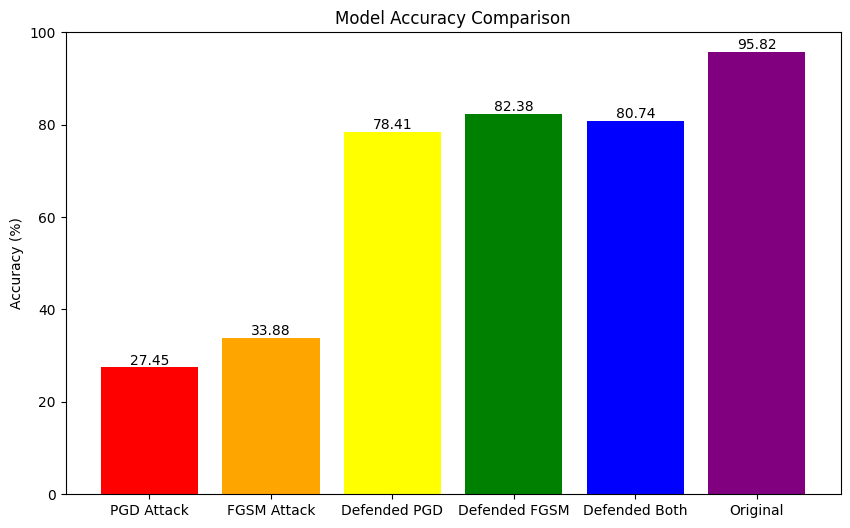

In [25]:
accuracies = {
    'PGD Attack': pgd_accuracy * 100,
    'FGSM Attack': fgsm_accuracy * 100,
    'Defended PGD': def_pgd_accuracy * 100,
    'Defended FGSM': def_fgsm_accuracy * 100,
    'Defended Both': def_both_accuracy * 100,
    'Original': original_accuracy * 100
}
labels = list(accuracies.keys())
values = list(accuracies.values())
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=['red','orange','yellow','green','blue','purple'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, round(yval, 2), va='bottom', ha='center')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.show()